# EDA - Hotel Booking Demand

**Pregunta:** ¿Podemos predecir si una reserva de hotel será cancelada?

**Variable objetivo (Y):** is_canceled (0 = No cancelada, 1 = Cancelada)

**Variables de entrada (X):** lead_time, tipo de hotel, país, precio, tipo de depósito, segmento de mercado y más



## Paso 1 - Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import json

print('Librerías importadas correctamente')

Librerías importadas correctamente


## Paso 2 - Cargar los datos

In [2]:
# Cargamos el CSV desde la misma carpeta
df = pd.read_csv('hotel_bookings.csv')

print('Filas y columnas:', df.shape)
df.head()

Filas y columnas: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Paso 3 - Familiarizarnos con los datos

In [3]:
# Tipos de datos y valores nulos por columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
# Estadísticos básicos de todas las variables numéricas
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [5]:
# Comprobamos si hay filas duplicadas
duplicados = df.duplicated().sum()
print(f'Filas duplicadas encontradas: {duplicados}')

# Eliminamos los duplicados
df = df.drop_duplicates()
print(f'Filas después de eliminar duplicados: {len(df)}')

Filas duplicadas encontradas: 31994
Filas después de eliminar duplicados: 87396


Distribución de cancelaciones:
is_canceled
0    63371
1    24025
Name: count, dtype: int64

Tasa de cancelación global: 27.49%


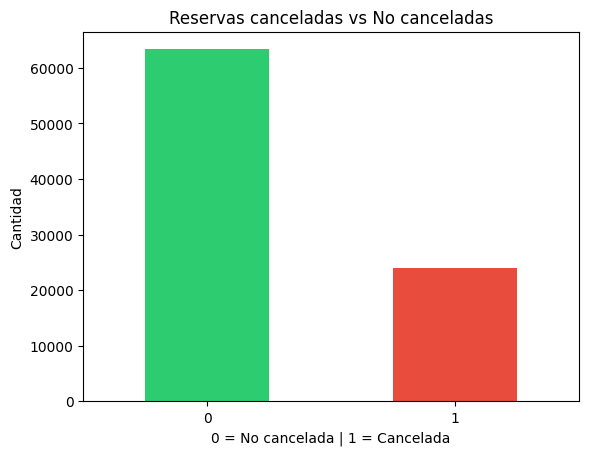

In [6]:
# Distribución de la variable objetivo: canceladas vs no canceladas
print('Distribución de cancelaciones:')
print(df['is_canceled'].value_counts())
print(f'\nTasa de cancelación global: {df["is_canceled"].mean()*100:.2f}%')

# Gráfico de barras
df['is_canceled'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Reservas canceladas vs No canceladas')
plt.xlabel('0 = No cancelada | 1 = Cancelada')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

## Paso 4 - Seleccionar variables

Eliminamos las variables que causan **data leakage** (hacen trampa) y las que no aportan:

- `reservation_status` → dice directamente si ya se canceló (trampa)
- `reservation_status_date` → fecha del estado final (trampa)
- `arrival_date_week_number` → redundante con el mes
- `arrival_date_day_of_month` → el día exacto no predice cancelaciones
- `company` → 94% de valores nulos, no aporta información

In [7]:
# Eliminamos las columnas problemáticas
columnas_eliminar = [
    'reservation_status',        # leakage: dice si ya se canceló
    'reservation_status_date',   # leakage: fecha del estado final
    'arrival_date_week_number',  # redundante con el mes
    'arrival_date_day_of_month', # poco predictivo
    'company'                    # 94% nulos
]

df = df.drop(columns=columnas_eliminar)

print('Dataset después de eliminar columnas:', df.shape)
df.head()

Dataset después de eliminar columnas: (87396, 27)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,0,0,2,0.0,0,...,C,C,3,No Deposit,NaN,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,0,0,2,0.0,0,...,C,C,4,No Deposit,NaN,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,0,1,1,0.0,0,...,A,C,0,No Deposit,NaN,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,0,1,1,0.0,0,...,A,A,0,No Deposit,304.0,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,0,2,2,0.0,0,...,A,A,0,No Deposit,240.0,0,Transient,98.0,0,1


## Paso 5 - Valores nulos

In [8]:
# Vemos cuántos nulos hay por columna
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
days_in_waiting_list                  0
customer_type                         0
adr          

In [9]:
# children: 4 nulos → rellenamos con 0 (sin niños)
df['children'] = df['children'].fillna(0)

# country: 488 nulos → rellenamos con 'Unknown'
df['country'] = df['country'].fillna('Unknown')

# agent: 16.340 nulos → rellenamos con 0 (sin agente)
df['agent'] = df['agent'].fillna(0)

# Eliminamos filas sin ningún huésped (error de datos)
df = df[~((df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0))]

print('Valores nulos después de la limpieza:', df.isnull().sum().sum())
print('Filas después de la limpieza:', len(df))

Valores nulos después de la limpieza: 0
Filas después de la limpieza: 87230


## Paso 6 - Outliers

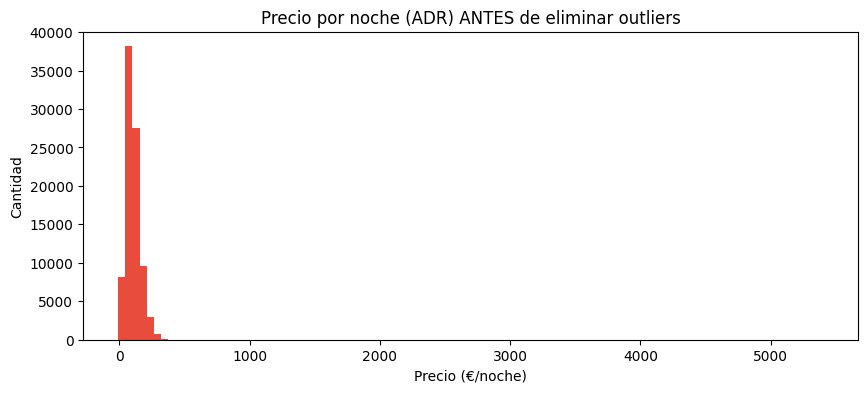

Precio máximo antes: 5400.0
Precio mínimo antes: -6.38


In [10]:
# Outliers en el precio (ADR) - ANTES
plt.figure(figsize=(10, 4))
plt.hist(df['adr'], bins=100, color='#e74c3c')
plt.title('Precio por noche (ADR) ANTES de eliminar outliers')
plt.xlabel('Precio (€/noche)')
plt.ylabel('Cantidad')
plt.show()

print(f'Precio máximo antes: {df["adr"].max()}')
print(f'Precio mínimo antes: {df["adr"].min()}')

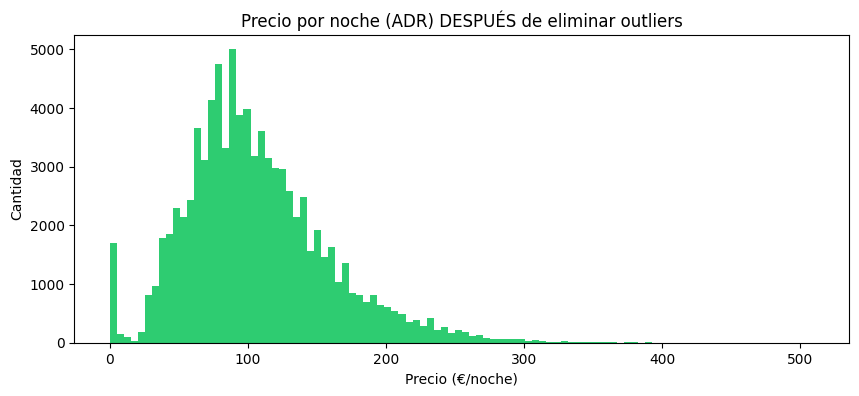

Filas después de eliminar outliers en ADR: 87228


In [11]:
# Eliminamos precios negativos o absurdamente altos (>5000€)
df = df[(df['adr'] >= 0) & (df['adr'] < 5000)]

# Outliers en el precio (ADR) - DESPUÉS
plt.figure(figsize=(10, 4))
plt.hist(df['adr'], bins=100, color='#2ecc71')
plt.title('Precio por noche (ADR) DESPUÉS de eliminar outliers')
plt.xlabel('Precio (€/noche)')
plt.ylabel('Cantidad')
plt.show()

print(f'Filas después de eliminar outliers en ADR: {len(df)}')

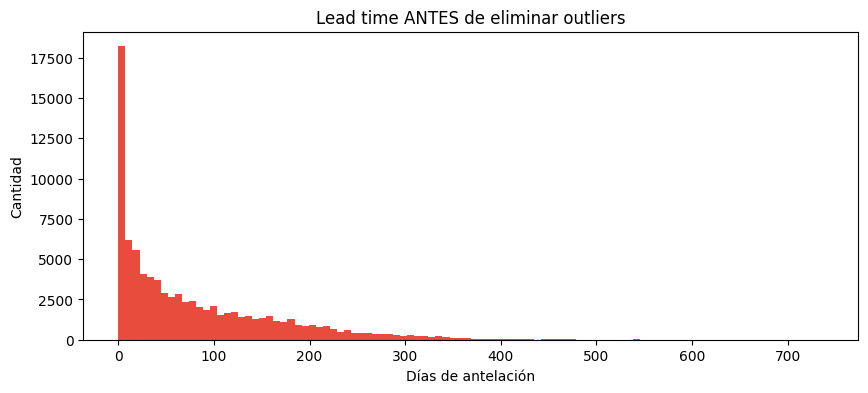

Lead time máximo antes: 737 días


In [12]:
# Outliers en lead_time (días de antelación) - ANTES
plt.figure(figsize=(10, 4))
plt.hist(df['lead_time'], bins=100, color='#e74c3c')
plt.title('Lead time ANTES de eliminar outliers')
plt.xlabel('Días de antelación')
plt.ylabel('Cantidad')
plt.show()

print(f'Lead time máximo antes: {df["lead_time"].max()} días')

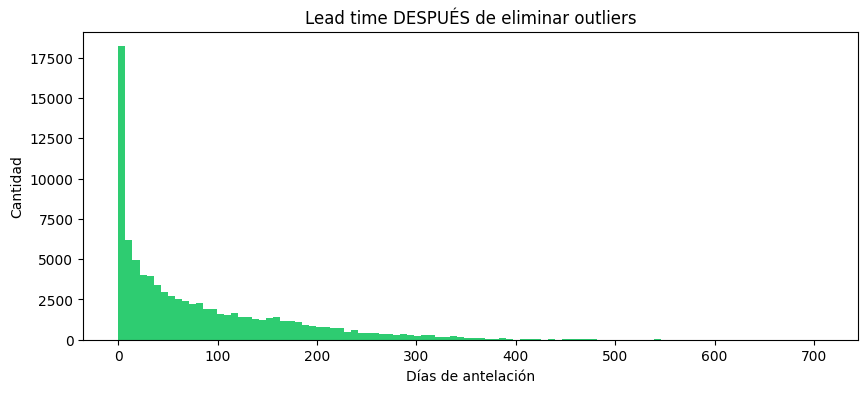

Filas después de eliminar outliers en lead_time: 87227


In [13]:
# Eliminamos lead_time extremos (más de 2 años de antelación = 730 días)
df = df[df['lead_time'] <= 730]

# Lead time - DESPUÉS
plt.figure(figsize=(10, 4))
plt.hist(df['lead_time'], bins=100, color='#2ecc71')
plt.title('Lead time DESPUÉS de eliminar outliers')
plt.xlabel('Días de antelación')
plt.ylabel('Cantidad')
plt.show()

print(f'Filas después de eliminar outliers en lead_time: {len(df)}')

## Paso 7 - Análisis exploratorio de variables clave

Analizamos qué variables tienen más relación con la cancelación

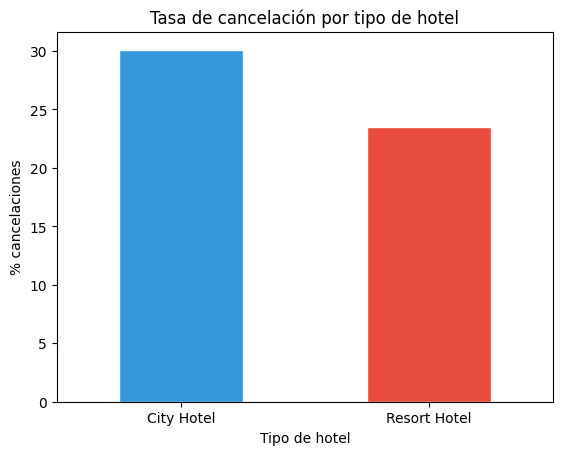

hotel
City Hotel      30.097798
Resort Hotel    23.484715
Name: is_canceled, dtype: float64


In [14]:
# Cancelaciones por tipo de hotel
cancel_hotel = df.groupby('hotel')['is_canceled'].mean() * 100

cancel_hotel.plot(kind='bar', color=['#3498db', '#e74c3c'], edgecolor='white')
plt.title('Tasa de cancelación por tipo de hotel')
plt.xlabel('Tipo de hotel')
plt.ylabel('% cancelaciones')
plt.xticks(rotation=0)
plt.show()

print(cancel_hotel)

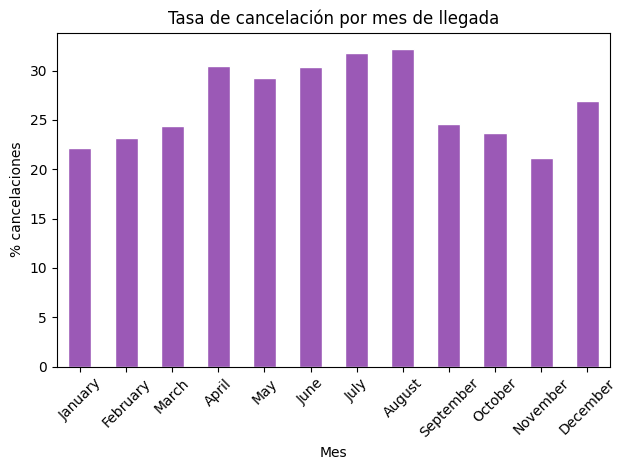

In [15]:
# Cancelaciones por mes de llegada
meses_orden = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

cancel_mes = df.groupby('arrival_date_month')['is_canceled'].mean() * 100
cancel_mes = cancel_mes.reindex(meses_orden)

cancel_mes.plot(kind='bar', color='#9b59b6', edgecolor='white')
plt.title('Tasa de cancelación por mes de llegada')
plt.xlabel('Mes')
plt.ylabel('% cancelaciones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

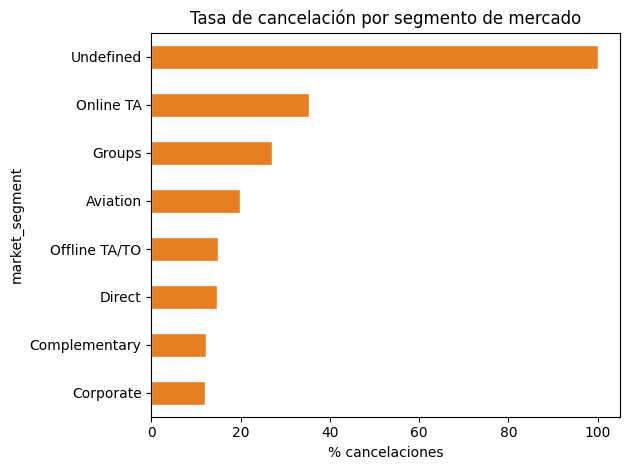

In [16]:
# Cancelaciones por segmento de mercado
cancel_segmento = df.groupby('market_segment')['is_canceled'].mean() * 100
cancel_segmento = cancel_segmento.sort_values()

cancel_segmento.plot(kind='barh', color='#e67e22', edgecolor='white')
plt.title('Tasa de cancelación por segmento de mercado')
plt.xlabel('% cancelaciones')
plt.tight_layout()
plt.show()

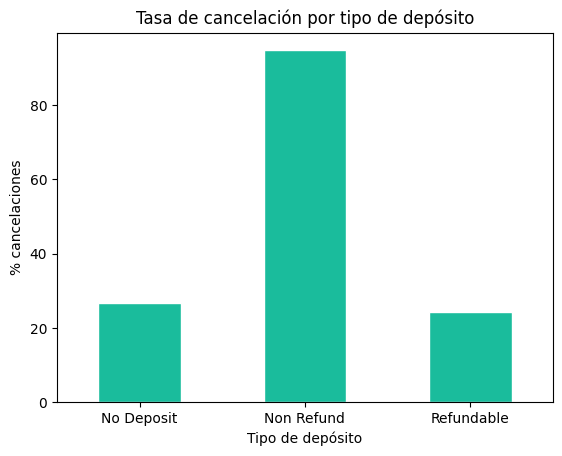

deposit_type
No Deposit    26.718400
Non Refund    94.696239
Refundable    24.299065
Name: is_canceled, dtype: float64


In [17]:
# Cancelaciones por tipo de depósito
cancel_deposito = df.groupby('deposit_type')['is_canceled'].mean() * 100

cancel_deposito.plot(kind='bar', color='#1abc9c', edgecolor='white')
plt.title('Tasa de cancelación por tipo de depósito')
plt.xlabel('Tipo de depósito')
plt.ylabel('% cancelaciones')
plt.xticks(rotation=0)
plt.show()

print(cancel_deposito)

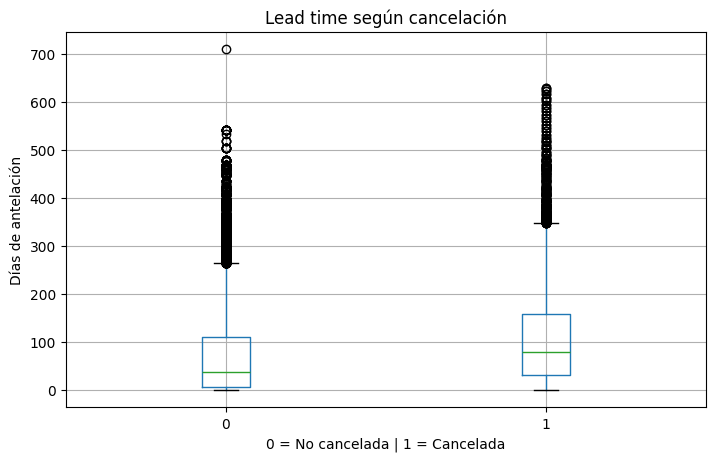

Lead time medio canceladas:    105.7 días
Lead time medio no canceladas: 70.2 días


In [18]:
# Boxplot: lead_time vs cancelación
# Muestra si reservar con más antelación está relacionado con cancelar
df.boxplot(column='lead_time', by='is_canceled', figsize=(8, 5))
plt.title('Lead time según cancelación')
plt.suptitle('')
plt.xlabel('0 = No cancelada | 1 = Cancelada')
plt.ylabel('Días de antelación')
plt.show()

# Comparamos medias
media_cancel = df[df['is_canceled']==1]['lead_time'].mean()
media_no_cancel = df[df['is_canceled']==0]['lead_time'].mean()
print(f'Lead time medio canceladas:    {media_cancel:.1f} días')
print(f'Lead time medio no canceladas: {media_no_cancel:.1f} días')

## Paso 8 - Matriz de correlación

La correlación mide cómo de relacionadas están dos variables numéricas:
- **Cercana a 1**: si una sube, la otra también sube
- **Cercana a -1**: si una sube, la otra baja
- **Cercana a 0**: no tienen relación

Nos interesa especialmente qué variables se correlacionan más con `is_canceled`

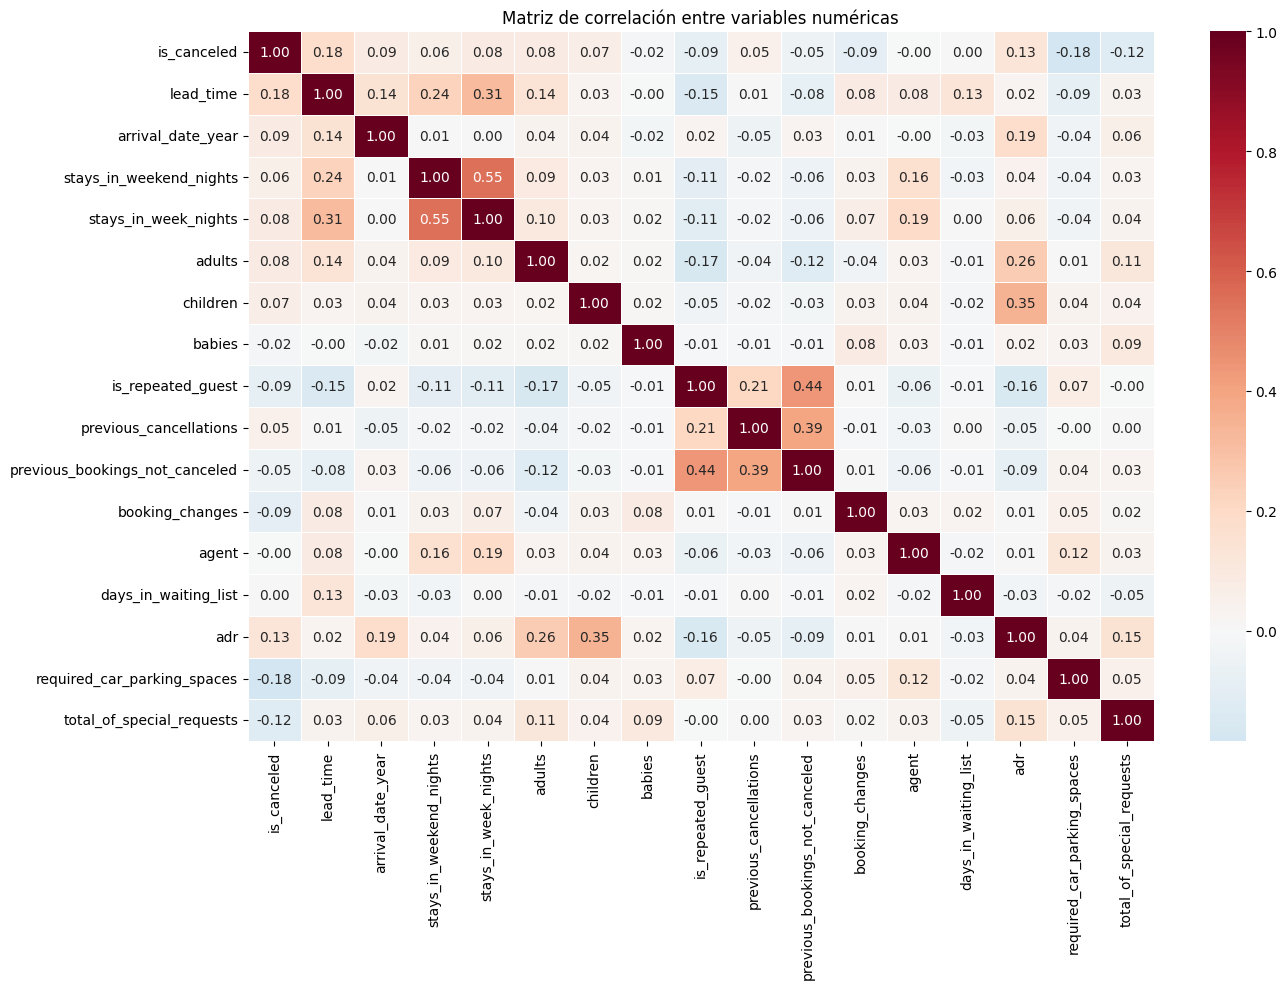

In [19]:
# Seleccionamos solo las columnas numéricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Calculamos la matriz de correlación
corr = df[num_cols].corr()

# Dibujamos el heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,       # muestra el número en cada celda
    fmt='.2f',        # con 2 decimales
    cmap='RdBu_r',    # rojo=negativo, azul=positivo
    center=0,
    linewidths=0.5
)
plt.title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()

In [20]:
# Variables más correlacionadas con is_canceled
corr_target = corr['is_canceled'].drop('is_canceled').sort_values(key=abs, ascending=False)

print('Variables más relacionadas con la cancelación:')
print(corr_target.to_string())

Variables más relacionadas con la cancelación:
lead_time                         0.184656
required_car_parking_spaces      -0.184459
adr                               0.132692
total_of_special_requests        -0.120794
booking_changes                  -0.093222
is_repeated_guest                -0.088741
arrival_date_year                 0.088025
stays_in_week_nights              0.084180
adults                            0.080271
children                          0.067185
stays_in_weekend_nights           0.061029
previous_bookings_not_canceled   -0.052170
previous_cancellations            0.051502
babies                           -0.020627
days_in_waiting_list              0.004711
agent                            -0.001126


## Paso 9 - Feature Engineering (nuevas variables)

Creamos nuevas variables que el modelo puede aprovechar mejor:

In [21]:
# Total de noches de estancia (entre semana + fin de semana)
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

# Total de huéspedes por reserva
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# Ingreso estimado total de la reserva (precio x noches)
df['revenue_estimate'] = df['adr'] * df['total_nights']

# Mes de llegada como número (enero=1, diciembre=12)
# Los modelos solo entienden números, no texto
mes_num = {
    'January':1, 'February':2, 'March':3, 'April':4,
    'May':5, 'June':6, 'July':7, 'August':8,
    'September':9, 'October':10, 'November':11, 'December':12
}
df['arrival_month_num'] = df['arrival_date_month'].map(mes_num)

# Eliminamos la columna de mes en texto (ya tenemos el número)
df = df.drop(columns=['arrival_date_month'])

print('Nuevas variables creadas:')
print('  total_nights:      noches totales de estancia')
print('  total_guests:      total de huéspedes')
print('  revenue_estimate:  ingreso estimado (adr x noches)')
print('  arrival_month_num: mes de llegada como número (1-12)')
print('\nDataset actual:', df.shape)

Nuevas variables creadas:
  total_nights:      noches totales de estancia
  total_guests:      total de huéspedes
  revenue_estimate:  ingreso estimado (adr x noches)
  arrival_month_num: mes de llegada como número (1-12)

Dataset actual: (87227, 30)


## Paso 10 - OneHotEncoder en variables categóricas

Los modelos de Machine Learning solo entienden números.
El **OneHotEncoder** convierte cada categoría en una columna nueva de 0s y 1s.

Por ejemplo: la columna `hotel` con valores 'City Hotel' y 'Resort Hotel'
se convierte en:
- `hotel_City Hotel` → 1 si es City Hotel, 0 si no
- `hotel_Resort Hotel` → 1 si es Resort Hotel, 0 si no

In [22]:
# Identificamos las columnas categóricas (texto)
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Columnas categóricas a encodear:', cat_cols)

Columnas categóricas a encodear: ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


C:\Users\34650\AppData\Local\Temp\ipykernel_6484\261272453.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [23]:
# Creamos el encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# fit_transform: aprende las categorías y las convierte en columnas de 0s y 1s
encoded = encoder.fit_transform(df[cat_cols])

# Creamos un DataFrame con las nuevas columnas
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=df.index
)

# Unimos las nuevas columnas al dataset original
df = pd.concat([df, encoded_df], axis=1)

# Eliminamos las columnas originales de texto
df = df.drop(columns=cat_cols)

print('Dataset con encoding:', df.shape)
df.head()

Dataset con encoding: (87227, 246)


,is_canceled,lead_time,arrival_date_year,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,...,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0,342,2015,0,0,2,0.0,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,7,2015,0,1,1,0.0,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,13,2015,0,1,1,0.0,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,14,2015,0,2,2,0.0,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
6,0,0,2015,0,2,2,0.0,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## Paso 11 - Definir X e Y y dividir Train/Test

In [24]:
# X son todas las variables predictoras (todo menos is_canceled)
X = df.drop(columns=['is_canceled'])

# Y es lo que queremos predecir
y = df['is_canceled']

# Guardamos los nombres de las features para usarlos en el Paso 6
FEATURES = X.columns.tolist()

# Dividimos: 80% para entrenar, 20% para evaluar
# stratify=y → misma proporción de cancelaciones en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Datos para entrenar:', X_train.shape)
print('Datos para el test: ', X_test.shape)
print(f'\nProporción cancelaciones en train: {y_train.mean()*100:.2f}%')
print(f'Proporción cancelaciones en test:  {y_test.mean()*100:.2f}%')

Datos para entrenar: (69781, 245)
Datos para el test:  (17446, 245)

Proporción cancelaciones en train: 27.52%
Proporción cancelaciones en test:  27.52%


## Paso 12 - Guardar archivos para el Paso 6

In [25]:
# Guardamos los datasets procesados en la misma carpeta
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv',   index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv',   index=False)

# Guardamos la lista de features para el Paso 6 y la app Streamlit
with open('features.json', 'w') as f:
    json.dump(FEATURES, f)

print('Archivos guardados correctamente:')
print('  X_train.csv →', X_train.shape)
print('  X_test.csv  →', X_test.shape)
print('  y_train.csv →', y_train.shape)
print('  y_test.csv  →', y_test.shape)
print('  features.json →', len(FEATURES), 'variables')

Archivos guardados correctamente:
  X_train.csv → (69781, 245)
  X_test.csv  → (17446, 245)
  y_train.csv → (69781,)
  y_test.csv  → (17446,)
  features.json → 245 variables
